In [9]:
!pip install vk_api

In [10]:
!pip install ollama

In [11]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [12]:
import requests
import time
import csv
import pickle
from collections import deque
import vk_api
import pandas as pd
import os
import random
import re
import ollama
import concurrent.futures
import openai

In [13]:
!pip install navec

In [14]:
# Параметры
from tqdm import tqdm
TOKEN = "____"
OWNER_ID = -30602036  # пример: id группы в формате отрицательного числа для сообщества
TARGET_COMMENTS = 3500
MIN_WORDS = 2
REQUEST_SLEEP = 0.34  # выдержка между вызовами
OUTPUT_DIR = r"C:\zadanie 1"
OUTPUT_CSV = os.path.join(OUTPUT_DIR, "vk_comments.csv")

# Инициализация
session = vk_api.VkApi(token=TOKEN)
vk = session.get_api()

def valid_comment_text(text, min_words=MIN_WORDS):
    if not text:
        return False
    words = [w for w in text.split() if w.strip()]
    return len(words) >= min_words

# Получим все id постов (из всех записей стены, с пагинацией)
def fetch_post_ids(owner_id, vk, target_count=100, max_per_call=100):
    post_ids = []
    offset = 0
    while len(post_ids) < target_count:
        count = min(max_per_call, target_count - len(post_ids))
        resp = vk.wall.get(owner_id=owner_id, count=count, offset=offset)
        items = resp.get('items', [])
        if not items:
            break
        post_ids.extend([it['id'] for it in items])
        offset += len(items)
        time.sleep(REQUEST_SLEEP)
    return post_ids

# Используем:
post_ids = fetch_post_ids(OWNER_ID, vk, target_count=100)
print("Найдено постов:", len(post_ids))

# Получение комментариев
def fetch_comments_for_post(owner_id, post_id, vk, max_per_call=100):
    comments = []
    offset = 0
    while True:
        try:
            resp = vk.wall.getComments(owner_id=owner_id, post_id=post_id, count=max_per_call, offset=offset, sort='asc', need_likes=0)
            items = resp.get('items', [])
            if not items:
                break
            for it in items:
                comments.append(it)
            if len(items) < max_per_call:
                break
            offset += max_per_call
            time.sleep(REQUEST_SLEEP)
        except Exception as e:
            print(f"Ошибка getComments (post {post_id}):", e)
            break
    return comments

collected = []

# Создаем прогресс-бар по количеству постов
for pid in tqdm(post_ids, desc="Сбор комментариев по постам"):
    comms = fetch_comments_for_post(OWNER_ID, pid, vk)
    for c in comms:
        text = c.get('text', '').strip()
        if not valid_comment_text(text):
            continue
        entry = {
            'group_id': OWNER_ID,
            'post_id': pid,
            'comment_id': c.get('id'),
            'user_id': c.get('from_id'),
            'text': text,
            'date': c.get('date')
        }
        collected.append(entry)
    if len(collected) >= TARGET_COMMENTS:
        break

# Сохраняем результаты
df = pd.DataFrame(collected)
df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f"Сохранено: {OUTPUT_CSV}, всего комментариев: {len(df)}")

Найдено постов: 100


Сбор комментариев по постам: 100%|██████████| 100/100 [01:02<00:00,  1.61it/s]

Сохранено: C:\zadanie 1\vk_comments.csv, всего комментариев: 2916


In [15]:
import ollama
from tqdm.notebook import tqdm
OUTPUT_DIR = r"C:\zadanie 1"
OUTPUT_CSV = os.path.join(OUTPUT_DIR, "vk_comments.csv")

df = pd.read_csv(OUTPUT_CSV, encoding="utf-8-sig")
print("Комментарии загружены:", len(df))

MODEL_NAME = "gemma3:1b"

def classify_comment(text: str) -> int:
    prompt = f"""
Проанализируй комментарий и определи одну категорию из списка:
0 — спам
1 — детская порнография
2 — экстремизм
3 — насилие
4 — пропаганда наркотиков
5 — материал для взрослых
6 — оскорбление
7 — нейтральные
8 — призывы к суициду

Ответь только числом категории, без пояснений.
Комментарий: "{text}"
    """

    try:
        response = ollama.generate(
            model=MODEL_NAME,
            prompt=prompt
        )
        answer = response["response"].strip()

        number = ''.join(ch for ch in answer if ch.isdigit())
        if number == "":
            return 7
        return int(number)

    except Exception as e:
        print("Ошибка классификации:", e)
        return 7

results = []
for i, row in tqdm(df.iterrows(), total=len(df), desc="Классификация"):
    category = classify_comment(row["text"])
    results.append(category)
   # time.sleep(0.05)

df["llm_category"] = results
OUTPUT_CSV_LABELED = os.path.join(OUTPUT_DIR, "vk_comments_llm.csv")
df.to_csv(OUTPUT_CSV_LABELED, index=False, encoding="utf-8-sig")

print("Готово. Файл сохранён.")

Комментарии загружены: 2916


Классификация:   0%|          | 0/2916 [00:00<?, ?it/s]

Готово. Файл сохранён.


In [16]:
import pandas as pd
from nltk.stem.snowball import RussianStemmer
from collections import Counter
import re
from sklearn.model_selection import train_test_split

df = pd.read_csv(OUTPUT_CSV_LABELED, encoding="utf-8-sig")
stemmer = RussianStemmer()
def preprocess_text(text):
    # Убираем лишние символы, оставляем только буквы и цифры
    text = re.sub(r'[^а-яА-ЯёЁ0-9\s]', ' ', text.lower())
    words = [stemmer.stem(w) for w in text.split() if w.strip()]
    return words
df['tokens'] = df['text'].apply(preprocess_text)

all_words = [w for tokens in df['tokens'] for w in tokens]
word_freq = Counter(all_words)

# Фильтруем редкие слова
MIN_FREQ = 10
df['tokens'] = df['tokens'].apply(lambda tokens: [w for w in tokens if word_freq[w] >= MIN_FREQ])
# Разделение на тренировочный и тестовый набор
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)
print("Тренировочный набор:", len(train_df))
print("Тестовый набор:", len(test_df))

# 3.2
marker_words = {
    0: [  # спам
        'спам', 'реклама', 'продам', 'куплю', 'скидка', 'акция', 'подарок', 'рассылка', 
        'продажа', 'товар', 'магазин', 'ссылка', 'перейди', 'кликни', 'бесплатно', 'выиграй',
        'приз', 'розыгрыш', 'подпишись', 'репост', 'халява', 'онлайн', 'заработок', 'миллион',
        'быстро', 'легко', 'гарантия', 'ссылка'],
    1: [  # детская порнография
        'детский', 'детская порнография', 'детские', 'детское порно'],
    2: [  # экстремизм
        'экстремизм', 'экстремист', 'террор', 'террорист', 'радикал', 'мятеж', 'восстание'],
    3: [  # насилие
        'убийство', 'убивать', 'убивает', 'насилие', 'насиловать', 'пытка', 
        'избиение', 'драка', 'удар', 'ранение', 'убили', 'убил'],
    4: [  # пропаганда наркотиков
        'наркотик', 'наркотики', 'косяк', 'травка', 'марихуана', 'гашиш', 'крэк'],
    5: [  # материал для взрослых
        'эротика', 'порно', 'взрослое', 'обнаженный', 'обнаженная', 'обнаженные', 
        'сексуальный', 'сексуальная', 'секс', 'интим', 'порнуха', 'порнушка'],
    6: [  # оскорбление
        'глупый', 'глупая', 'глупые', 'идиот', 'идиотка', 'тупой', 'тупая', 'тупые', 
        'дурак', 'дура', 'негодяй', 'мразь', 'кретин', 'придурок', 'блять', 'дебил', 'даун', 'долбоёб', 'ублюдок', 'скотина', 'сволочь', 'подонок',
        'мудак', 'урод', 'хуйло', 'тварь', 'сука', 'падла', 'стерва', 'гандон',
        'чмо', 'приспособленец', 'хуев', 'пизда', 'говно', 'жопа', 'засранец',
        'лох', 'олух', 'олень', 'козёл', 'осёл', 'свинья', 'блядь', 'шлюха', 'бздун', 'выблядок', 'выёбок', 'гавно', 'гнида', 'грёбаный', 'дерьмо',
        'дрочила', 'залупа', 'козлина', 'конча', 'курва', 'манда', 'мокрощёлка',
        'мусор', 'недоделок', 'недоносок', 'невъебенный', 'отброс', 'отстой',
        'падлюка', 'пиздюк', 'поебота', 'сучка', 'толстожопый', 'тряпка',
        'уёбище', 'упырь', 'хуеплет', 'шалава'],
    7: [],  # нейтральные
    8: [  # призывы к суициду
        'суицид', 'убиться', 'повеситься', 'покончить с собой', 'самоубийство', 
        'самоубийца', 'повеситься', 'убейся']
}
# Стемминг маркерных слов
for cat in marker_words:
    marker_words[cat] = [stemmer.stem(w) for w in marker_words[cat]]
def classify_by_markers(tokens, marker_words, threshold=1):
    freqs = {}
    for cat, markers in marker_words.items():
        if markers:
            freqs[cat] = sum(tokens.count(m) for m in markers)
        else:
            freqs[cat] = 0
    # Выбираем категорию с максимальной частотой
    max_cat = max(freqs, key=freqs.get)
    if freqs[max_cat] < threshold:
        return 7  # нейтральные
    return max_cat

train_df['marker_cat'] = train_df['tokens'].apply(lambda t: classify_by_markers(t, marker_words))
test_df['marker_cat'] = test_df['tokens'].apply(lambda t: classify_by_markers(t, marker_words))


Тренировочный набор: 2332
Тестовый набор: 584


In [20]:
import numpy as np
from navec import Navec
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.notebook import tqdm
# Загружаем модель Navec
navec_path = r"C:\zadanie 1\navec_hudlit_v1_12B_500K_300d_100q.tar"
navec = Navec.load(navec_path)
print("Модель Navec загружена")
def word_vector(word):
    """
    Возвращает вектор слова из Navec.
    Если слова нет в словаре — возвращает нули.
    """
    if word in navec.vocab:
        return navec[word]
    else:
        # безопасно узнаём размерность через pq
        dim = navec.pq.d if hasattr(navec.pq, 'd') else len(navec.pq[0])
        return np.zeros(dim)
def classify_by_embeddings(tokens, marker_words, navec):
    cat_scores = {}
    for cat, markers in marker_words.items():
        if not markers:
            cat_scores[cat] = 0
            continue
        marker_vecs = [word_vector(m) for m in markers]
        scores = []
        for token in tokens:
            vec = word_vector(token)
            if np.any(vec):  # если не нулевой вектор
                sims = [cosine_similarity([vec], [mv])[0][0] for mv in marker_vecs]
                scores.append(max(sims))
        cat_scores[cat] = np.mean(scores) if scores else 0
    max_cat = max(cat_scores, key=cat_scores.get)
    if cat_scores[max_cat] == 0:
        return 7  # нейтральные
    return max_cat
train_embed_cats = []
for tokens in tqdm(train_df['tokens'], desc="Train Embeddings"):
    train_embed_cats.append(classify_by_embeddings(tokens, marker_words, navec))
train_df['embed_cat'] = train_embed_cats

test_embed_cats = []
for tokens in tqdm(test_df['tokens'], desc="Test Embeddings"):
    test_embed_cats.append(classify_by_embeddings(tokens, marker_words, navec))
test_df['embed_cat'] = test_embed_cats

print("Классификация через Navec завершена!")

Модель Navec загружена


Train Embeddings:   0%|          | 0/2332 [00:00<?, ?it/s]

Test Embeddings:   0%|          | 0/584 [00:00<?, ?it/s]

Классификация через Navec завершена!


In [21]:
import os
import pandas as pd

OUTPUT_DIR = r"C:\zadanie 1"
OUTPUT_CSV_LABELED = os.path.join(OUTPUT_DIR, "vk_comments_llm.csv")

df = pd.read_csv(OUTPUT_CSV_LABELED, encoding="utf-8-sig")


category_names = {
    0: "спам",
    1: "детская порнография",
    2: "экстремизм",
    3: "насилие",
    4: "пропаганда наркотиков",
    5: "материал для взрослых",
    6: "оскорбление",
    7: "нормальный",
    8: "призывы к суициду"
}
import pandas as pd

df = pd.read_csv(OUTPUT_CSV_LABELED, encoding="utf-8-sig")

total_comments = len(df)

stats = (
    df["llm_category"]
    .value_counts()
    .sort_index()
    .reset_index()
)

stats.columns = ["category", "count"]
stats["percent"] = (stats["count"] / total_comments * 100).round(1)
stats["name"] = stats["category"].map(category_names)

print("Распределение по категориям:")
print("-" * 55)
print(f"{'Категория':25s} {'Кол-во':>8s} {'%':>6s}")
print("-" * 55)

for _, row in stats.iterrows():
    print(f"{row['name']:25s} {row['count']:8d} {row['percent']:6.1f}")


Распределение по категориям:
-------------------------------------------------------
Категория                   Кол-во      %
-------------------------------------------------------
экстремизм                       3    0.1
насилие                         52    1.8
пропаганда наркотиков            2    0.1
материал для взрослых          494   16.9
оскорбление                   2150   73.7
нормальный                     213    7.3
призывы к суициду                2    0.1


In [22]:
print("\n\nПРИМЕРЫ КОММЕНТАРИЕВ ПО КАТЕГОРИЯМ")
print("=" * 70)

for cat, name in category_names.items():
    subset = df[df["llm_category"] == cat]

    if len(subset) == 0:
        continue

    print(f"\n{name.upper()}:")

    examples = subset["text"].head(2).tolist()

    for i, text in enumerate(examples, 1):
        print(f"{i}. {text}")




ПРИМЕРЫ КОММЕНТАРИЕВ ПО КАТЕГОРИЯМ

ЭКСТРЕМИЗМ:
1. Хорошо, что я принципиальный F2P )
2. ООО «тмыв»

НАСИЛИЕ:
1. У меня дома до сих пор комп стоит 2004-2006 года и до сих пор работаю в Ворде и эксель там и презентации делаю.
2. Для 2008 года, сборка топовая. Call of duty 2 и Tomb Raider: Legend вышли немного раньше и должны летать на таком железе. Вот первый Crysis - уже серьезный тест)

ПРОПАГАНДА НАРКОТИКОВ:
1. 6200р стандарт
10500р расширенное
Если вдруг кому полезно будет
2. Где кукла ренни из ельдена?

МАТЕРИАЛ ДЛЯ ВЗРОСЛЫХ:
1. Мое детство было на XP 😌
2. Щегол какой то ,видно что родился в 00-х ,лучшебы как я в 90-х ,и на компе установлены бы либы : Они,хэви метал фак 2,Ярость ,Крутой Сэм,и моник выпуклый 17 дюймов с пентиумом 3 )))

ОСКОРБЛЕНИЕ:
1. Я оттуда только только выбрался и не хочу возвращаться
2. Виста? Он извращенец

НОРМАЛЬНЫЙ:
1. Я не плачу! Просто ностальгия в сердце попала😭
2. То чувство, когда твоё дество пришлось на дос и 95-98 винду…

ПРИЗЫВЫ К СУИЦИДУ:
1. Как

=== Accuracy ===
Маркерные слова: 0.0873
Эмбеддинги:      0.5205

=== Macro F1 ===
Маркерные слова: 0.0358
Эмбеддинги:      0.1030


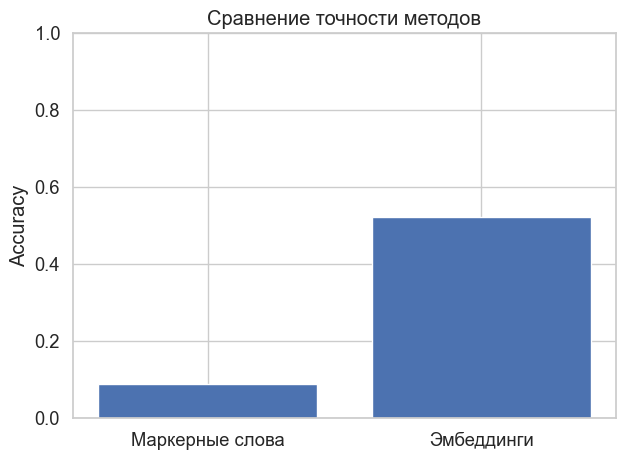

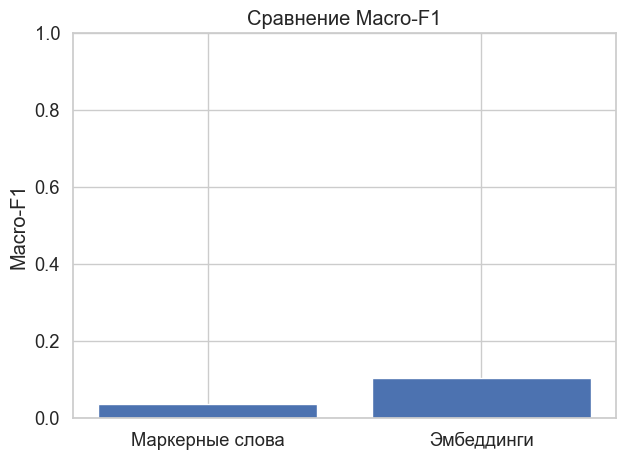

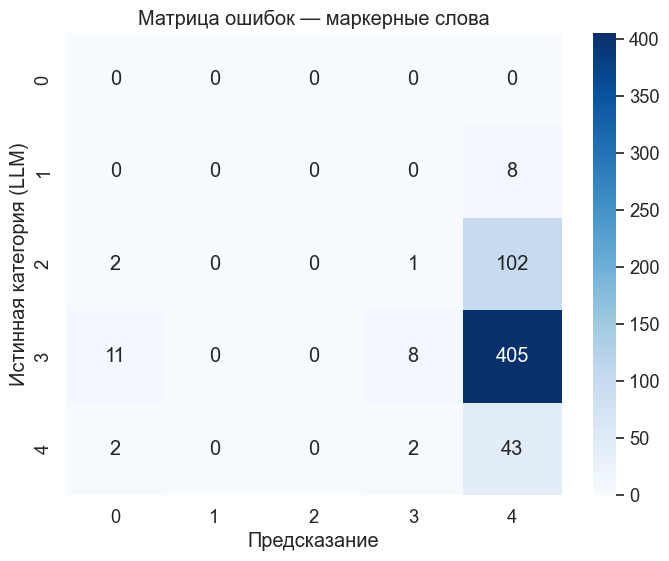

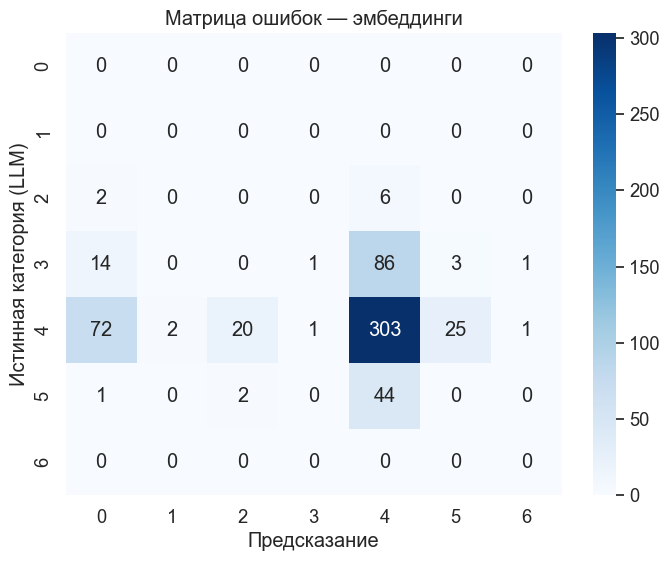

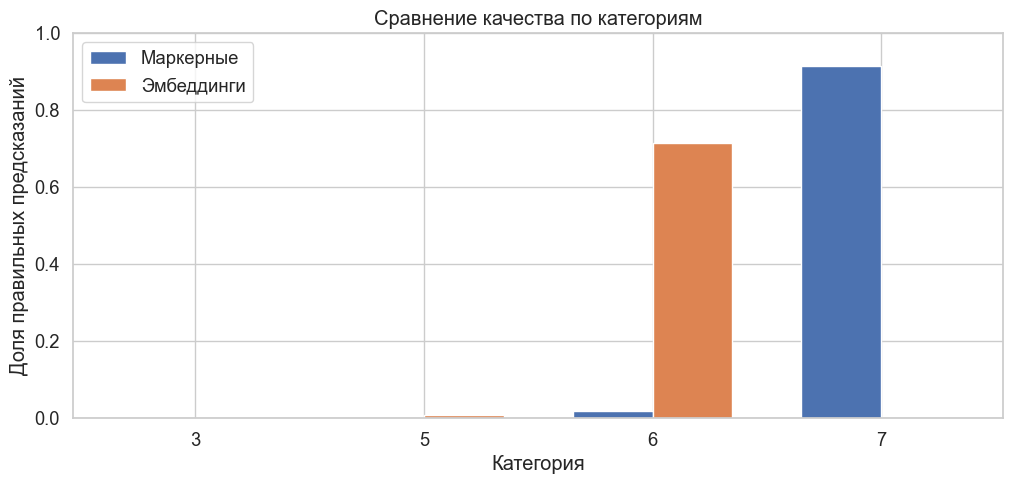


=== Сравнительная таблица ===
              Метод  Accuracy  Macro-F1
0   Маркерные слова  0.087329  0.035786
1  Эмбеддинги Navec  0.520548  0.102985


In [23]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="whitegrid", font_scale=1.2)
test = test_df.copy()

#1 Accuracy
acc_marker = accuracy_score(test["llm_category"], test["marker_cat"])
acc_embed = accuracy_score(test["llm_category"], test["embed_cat"])

#2 F1
f1_marker = f1_score(test["llm_category"], test["marker_cat"], average="macro")
f1_embed = f1_score(test["llm_category"], test["embed_cat"], average="macro")

print("=== Accuracy ===")
print(f"Маркерные слова: {acc_marker:.4f}")
print(f"Эмбеддинги:      {acc_embed:.4f}")

print("\n=== Macro F1 ===")
print(f"Маркерные слова: {f1_marker:.4f}")
print(f"Эмбеддинги:      {f1_embed:.4f}")


#ГРАФИК 1  Accuracy сравнение


plt.figure(figsize=(7,5))
plt.bar(["Маркерные слова", "Эмбеддинги"],
        [acc_marker, acc_embed])
plt.ylabel("Accuracy")
plt.title("Сравнение точности методов")
plt.ylim(0, 1)
plt.show()

#ГРАФИК 2 Macro-F1 сравнение

plt.figure(figsize=(7,5))
plt.bar(["Маркерные слова", "Эмбеддинги"],
        [f1_marker, f1_embed])
plt.ylabel("Macro-F1")
plt.title("Сравнение Macro-F1")
plt.ylim(0, 1)
plt.show()

#ГРАФИК 3  Матрицы ошибок

def plot_conf_matrix(true, pred, title):
    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Предсказание")
    plt.ylabel("Истинная категория (LLM)")
    plt.title(title)
    plt.show()
plot_conf_matrix(test["llm_category"], test["marker_cat"], "Матрица ошибок — маркерные слова")
plot_conf_matrix(test["llm_category"], test["embed_cat"], "Матрица ошибок — эмбеддинги")

#ГРАФИК 4 сравнение по каждой категории

cats = sorted(test["llm_category"].unique())
marker_correct = []
embed_correct = []

for c in cats:
    true_mask = (test["llm_category"] == c)
    marker_correct.append((test["marker_cat"][true_mask] == c).mean())
    embed_correct.append((test["embed_cat"][true_mask] == c).mean())

x = np.arange(len(cats))
width = 0.35

plt.figure(figsize=(12,5))
plt.bar(x - width/2, marker_correct, width, label="Маркерные")
plt.bar(x + width/2, embed_correct, width, label="Эмбеддинги")

plt.xticks(x, cats)
plt.xlabel("Категория")
plt.ylabel("Доля правильных предсказаний")
plt.title("Сравнение качества по категориям")
plt.ylim(0, 1)
plt.legend()
plt.show()

#Итоговая таблица
comparison_table = pd.DataFrame({
    "Метод": ["Маркерные слова", "Эмбеддинги Navec"],
    "Accuracy": [acc_marker, acc_embed],
    "Macro-F1": [f1_marker, f1_embed]
})

print("\n=== Сравнительная таблица ===")
print(comparison_table)
